# Smart Driver Scoring System - Model Training

This notebook trains the driving behaviour classifier for my FYP. The dataset is a combination of Kaggle OBD-II data, some synthetic data I generated to match my car sensor ranges, and real trip CSVs recorded from my own car.

Labels are assigned using rule-based logic (Balanced v2) based on RPM, throttle, engine load and speed changes.

I am using 41 features in total (raw signals + deltas + rolling stats + ratios), a 70/15/15 stratified split, and SMOTE to handle the class imbalance.

The four experiments are:
1. Compare LR, DT, RF and HistGradBoost on validation set
2. Feature ablation - does adding more feature groups actually help?
3. Leave-one-driver-out - check if the model generalises across drivers
4. Learning curve - make sure the model is not overfitting

Final model and scaler are saved to src/models/

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import json
import warnings
from datetime import datetime

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
os.makedirs('src/models', exist_ok=True)
os.makedirs('docs/figures', exist_ok=True)

print("Setup complete.")

Setup complete.


## Stage 1 - Load and Combine Datasets

Three data sources are used here. The Kaggle OBD-II dataset gives us multi-driver real driving data. I also created synthetic data tuned to my own car's typical sensor readings (mostly urban driving). Finally I have a few real trips I recorded myself using the OBD dongle and the Android app.

In [2]:
SIGNAL_COLS = [
    'speed', 'rpm', 'throttle', 'engine_load',
    'relative_throttle', 'steering_angle', 'steering_speed'
]

### 1A - Kaggle OBD-II Data

In [3]:
RAW_PATH = "data/Kaggle/OBD-II Driving Data - Classified.csv"
df_raw = pd.read_csv(RAW_PATH, encoding='latin-1')

col_map = {
    df_raw.columns[1]:  'engine_load',
    df_raw.columns[6]:  'rpm',
    df_raw.columns[7]:  'speed',
    df_raw.columns[10]: 'throttle',
    df_raw.columns[24]: 'relative_throttle',
    df_raw.columns[31]: 'steering_angle',
    df_raw.columns[32]: 'steering_speed',
    df_raw.columns[34]: 'driver_id',
}
df_kaggle = df_raw.rename(columns=col_map)[SIGNAL_COLS + ['driver_id']].copy()
for c in SIGNAL_COLS:
    df_kaggle[c] = pd.to_numeric(df_kaggle[c], errors='coerce')
df_kaggle['driver_id'] = pd.to_numeric(df_kaggle['driver_id'], errors='coerce')
df_kaggle = df_kaggle.dropna()

# Balanced-v2 rule-based labelling
df_kaggle = df_kaggle.sort_values('driver_id').reset_index(drop=True)
df_kaggle['speed_diff'] = df_kaggle.groupby('driver_id')['speed'].diff().fillna(0)
df_kaggle['label'] = 0
agg_mask = (
    ((df_kaggle['rpm'] > 2700) & (df_kaggle['throttle'] > 30)) |
    ((df_kaggle['engine_load'] > 92) & (df_kaggle['throttle'] > 30)) |
    (df_kaggle['speed_diff'] > 12) |    # harsh acceleration: >12 km/h per step
    (df_kaggle['speed_diff'] < -10)     # harsh braking:      >10 km/h drop per step
)
df_kaggle.loc[agg_mask, 'label'] = 1
df_kaggle = df_kaggle.drop(columns=['speed_diff'])

print(f"[A] Kaggle rows   : {len(df_kaggle):,}")
print(f"    Safe={( df_kaggle['label']==0).sum():,}  Aggressive={(df_kaggle['label']==1).sum():,}")
df_kaggle[SIGNAL_COLS].describe()

[A] Kaggle rows   : 555,000
    Safe=169,598  Aggressive=385,402


,speed,rpm,throttle,engine_load,relative_throttle,steering_angle,steering_speed
count,555000.000000,555000.000000,555000.000000,555000.000000,555000.000000,555000.000000,555000.000000
mean,53.060142,2060.768771,29.448138,37.505999,19.411403,-12.777236,11.097605
std,33.185378,679.339149,24.856185,32.742429,24.699950,48.099359,23.827907
min,0.000000,652.000000,9.800000,0.000000,0.000000,-292.210000,0.000000
25%,22.000000,1612.000000,15.700000,9.100000,5.900000,-5.400000,0.000000
50%,55.000000,2082.000000,18.400000,28.200000,8.200000,0.000000,1.400000
75%,82.000000,2534.000000,25.900000,63.500000,15.700000,1.600000,9.600000
max,136.000000,3831.000000,88.200000,100.000000,78.000000,237.310000,195.940000


### 1B - Car-Specific Synthetic Data

In [4]:
np.random.seed(42)
N_SYN = 20000

syn_speed = np.concatenate([
    np.zeros(N_SYN // 5),
    np.random.uniform(5, 55, N_SYN * 4 // 5)
])
np.random.shuffle(syn_speed)
syn_rpm = np.where(syn_speed < 3,
                   np.random.uniform(700, 1100, N_SYN),
                   np.random.uniform(800, 2800, N_SYN))
syn_throttle  = np.random.uniform(13, 42, N_SYN)
syn_load      = np.where(syn_speed < 3,
                         np.random.uniform(0, 35, N_SYN),
                         np.random.uniform(45, 100, N_SYN))
syn_rel_thr   = np.random.uniform(0, 20, N_SYN)
syn_steer     = np.zeros(N_SYN)
syn_steer_spd = np.zeros(N_SYN)

syn_speed_diff = np.diff(syn_speed, prepend=syn_speed[0])
syn_label = (
    ((syn_rpm > 2700) & (syn_throttle > 30)) |
    ((syn_load > 92)  & (syn_throttle > 30)) |
    (syn_speed_diff > 12) |
    (syn_speed_diff < -10)
).astype(int)

df_syn = pd.DataFrame({
    'speed': syn_speed, 'rpm': syn_rpm, 'throttle': syn_throttle,
    'engine_load': syn_load, 'relative_throttle': syn_rel_thr,
    'steering_angle': syn_steer, 'steering_speed': syn_steer_spd,
    'label': syn_label, 'driver_id': 4
})

print(f"[B] Synthetic rows: {len(df_syn):,}")
print(f"    Safe={(df_syn['label']==0).sum():,}  Aggressive={(df_syn['label']==1).sum():,}")

[B] Synthetic rows: 20,000
    Safe=6,195  Aggressive=13,805


### 1C - Real Trip CSVs

In [5]:
TRIP_PATHS = [
    'data/trips/trip_20260329_172609.csv',
    'data/trips/trip_20260330_095440.csv',
    'data/trips/trip_20260331_190000.csv',
]
trip_frames = []
for p in TRIP_PATHS:
    t = pd.read_csv(p)
    rel_thr = t['relative_throttle'] if 'relative_throttle' in t.columns else 0.0
    t = t[['speed', 'rpm', 'throttle', 'engine_load']].copy()
    t['relative_throttle'] = rel_thr
    t['steering_angle']    = 0.0
    t['steering_speed']    = 0.0
    t['speed_diff'] = t['speed'].diff().fillna(0)
    t['label'] = 0
    agg_t = (
        ((t['rpm'] > 2700) & (t['throttle'] > 30)) |
        ((t['engine_load'] > 92) & (t['throttle'] > 30)) |
        (t['speed_diff'] > 12) |
        (t['speed_diff'] < -10)
    )
    t.loc[agg_t, 'label'] = 1
    t = t.drop(columns=['speed_diff'])
    t['driver_id'] = 5
    trip_frames.append(t)

df_trips = pd.concat(trip_frames, ignore_index=True)
print(f"[C] Real trip rows: {len(df_trips):,}")
print(f"    Safe={(df_trips['label']==0).sum():,}  Aggressive={(df_trips['label']==1).sum():,}")

[C] Real trip rows: 571
    Safe=490  Aggressive=81


### 1D - Combine Everything

Combined rows     : 426,468  (removed 149,103 dupes/nulls)
Drivers           : [1, 2, 3, 4, 5]
Label 0 (Safe)    : 138,782
Label 1 (Aggr.)   : 287,686


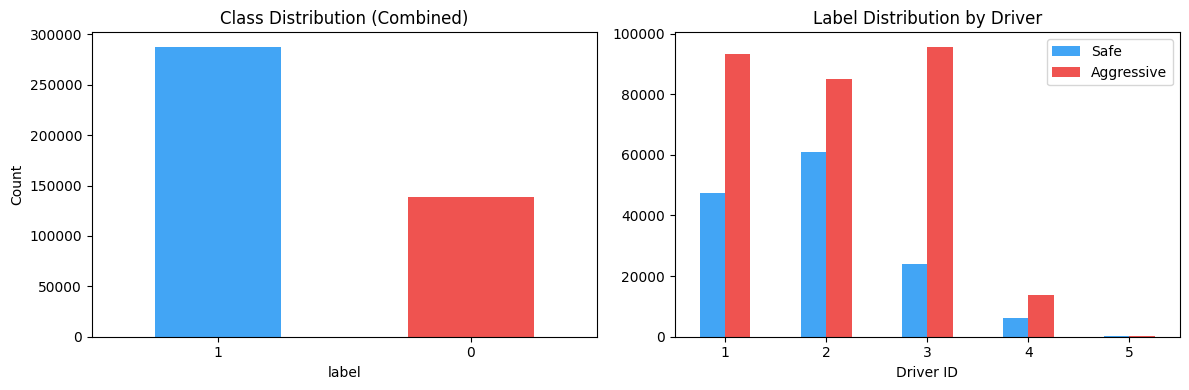

In [6]:
USE_COLS = SIGNAL_COLS + ['label', 'driver_id']
df = pd.concat([
    df_kaggle[USE_COLS],
    df_syn[USE_COLS],
    df_trips[USE_COLS],
], ignore_index=True)

before = len(df)
df = df.dropna().drop_duplicates(subset=SIGNAL_COLS + ['label'])

print(f"Combined rows     : {len(df):,}  (removed {before - len(df):,} dupes/nulls)")
print(f"Drivers           : {sorted(df['driver_id'].unique().astype(int).tolist())}")
print(f"Label 0 (Safe)    : {(df['label']==0).sum():,}")
print(f"Label 1 (Aggr.)   : {(df['label']==1).sum():,}")

# Label distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().plot.bar(ax=axes[0], color=['#42A5F5','#EF5350'],
                                     tick_label=['Safe','Aggressive'])
axes[0].set_title('Class Distribution (Combined)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df.groupby(['driver_id','label']).size().unstack(fill_value=0).plot.bar(
    ax=axes[1], color=['#42A5F5','#EF5350'])
axes[1].set_title('Label Distribution by Driver')
axes[1].set_xlabel('Driver ID')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Safe','Aggressive'])
plt.tight_layout()
plt.show()

## Stage 2 - Preprocessing

Before doing anything else, I clip the outliers at the 1st and 99th percentile to avoid extreme values messing up the scaler. Then MinMax scaling brings all signals into the 0-1 range.

In [7]:
# Clip outliers
for c in SIGNAL_COLS:
    lo, hi = df[c].quantile(0.01), df[c].quantile(0.99)
    df[c] = df[c].clip(lo, hi)

# MinMax scale
scaler = MinMaxScaler()
df[SIGNAL_COLS] = scaler.fit_transform(df[SIGNAL_COLS])

print("Scaling complete. Signal ranges after scaling:")
df[SIGNAL_COLS].agg(['min','max']).T

Scaling complete. Signal ranges after scaling:


,min,max
speed,0.0,1.0
rpm,0.0,1.0
throttle,0.0,1.0
engine_load,0.0,1.0
relative_throttle,0.0,1.0
steering_angle,0.0,1.0
steering_speed,0.0,1.0


## Stage 3 - Feature Engineering

Raw signals alone are not enough. I engineered three extra groups on top of the 7 base signals:
- **Deltas** (speed, rpm, throttle, engine load, steering) - captures rate of change
- **Rolling mean and std** with windows of 5, 10 and 15 - captures short-term driving patterns
- **Ratios** like rpm/speed and throttle/load - helps separate aggressive from normal

This gives 41 features total (7 + 5 + 24 + 5).

In [8]:
df = df.sort_values('driver_id').reset_index(drop=True)

# Group B: Delta
DELTA_PAIRS = ['speed', 'rpm', 'throttle', 'engine_load', 'steering_angle']
for c in DELTA_PAIRS:
    df[f'{c}_delta'] = df.groupby('driver_id')[c].diff().fillna(0)

# Group C: Rolling mean + std
ROLL_COLS = ['speed', 'rpm', 'throttle', 'engine_load']
WINDOWS   = [5, 10, 15]
for w in WINDOWS:
    for c in ROLL_COLS:
        df[f'{c}_mean_{w}'] = df.groupby('driver_id')[c].transform(
            lambda x: x.rolling(w, min_periods=w).mean()
        )
        df[f'{c}_std_{w}'] = df.groupby('driver_id')[c].transform(
            lambda x: x.rolling(w, min_periods=w).std().fillna(0)
        )

# Group D: Ratio features
df['rpm_speed_ratio']     = df['rpm']      / df['speed'].clip(lower=0.01)
df['throttle_load_ratio'] = df['throttle'] / df['engine_load'].clip(lower=0.01)
df['steering_activity']   = df['steering_angle'].abs() + df['steering_speed'].abs()
df['throttle_rpm_ratio']  = df['throttle'] / df['rpm'].clip(lower=0.01)
df['load_speed_ratio']    = df['engine_load'] / df['speed'].clip(lower=0.01)

df = df.dropna()

# Build feature group lists
GROUP_A = SIGNAL_COLS
GROUP_B = [f'{c}_delta' for c in DELTA_PAIRS]
GROUP_C = [f'{c}_{s}_{w}' for w in WINDOWS for c in ROLL_COLS for s in ['mean','std']]
GROUP_D = ['rpm_speed_ratio', 'throttle_load_ratio', 'steering_activity',
           'throttle_rpm_ratio', 'load_speed_ratio']
ALL_FEATURES = GROUP_A + GROUP_B + GROUP_C + GROUP_D

print(f"Feature groups: A(raw)={len(GROUP_A)}, B(delta)={len(GROUP_B)}, "
      f"C(rolling)={len(GROUP_C)}, D(ratio)={len(GROUP_D)}")
print(f"Total features : {len(ALL_FEATURES)}")
print(f"Samples        : {len(df):,}")

Feature groups: A(raw)=7, B(delta)=5, C(rolling)=24, D(ratio)=5
Total features : 41
Samples        : 426,398


## Stage 4 - Train/Val/Test Split and SMOTE

Split is 70/15/15 stratified. SMOTE is only applied to the training fold - I kept val and test clean so evaluation is not inflated.

Train : 298,648  |  Val : 63,790  |  Test : 63,960
After SMOTE â€” Train: 402,962  (Safe: 201,481 | Aggressive: 201,481)


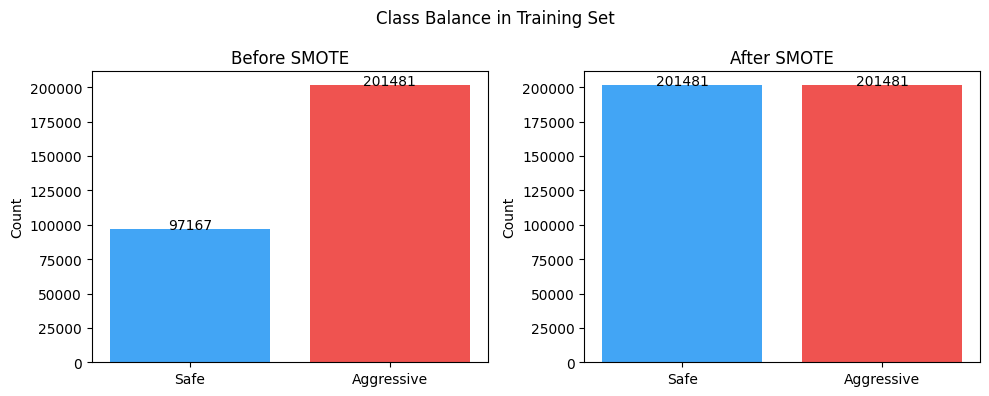

In [9]:
X_all = df[ALL_FEATURES].values
y_all = df['label'].values.astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}")

# SMOTE on training fold only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"After SMOTE â€” Train: {len(X_train_sm):,}  "
      f"(Safe: {(y_train_sm==0).sum():,} | Aggressive: {(y_train_sm==1).sum():,})")

# Visualise SMOTE effect
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [np.bincount(y_train), np.bincount(y_train_sm)],
    ['Before SMOTE', 'After SMOTE']
):
    ax.bar(['Safe','Aggressive'], counts, color=['#42A5F5','#EF5350'])
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts):
        ax.text(i, v + 50, str(v), ha='center', fontsize=10)
plt.suptitle('Class Balance in Training Set')
plt.tight_layout()
plt.show()

## Experiment 1 - Baseline Model Comparison

I trained four models to see which one works best before committing to anything. All trained on the SMOTE-balanced training set and evaluated on the validation set.

In [10]:
MODELS = {
    'Logistic Regression':   LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree':          DecisionTreeClassifier(
        max_depth=10, class_weight='balanced', random_state=42),
    'Random Forest':          RandomForestClassifier(
        n_estimators=100, max_depth=15, class_weight='balanced',
        n_jobs=-1, random_state=42),
    'HistGradientBoosting':   HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=500, max_depth=8,
        class_weight='balanced', random_state=42),
}

comparison_results = []
trained_models = {}

for name, mdl in MODELS.items():
    mdl.fit(X_train_sm, y_train_sm)
    trained_models[name] = mdl

    yv_pred = mdl.predict(X_val)
    yv_prob = mdl.predict_proba(X_val)[:, 1] if hasattr(mdl, 'predict_proba') else None
    auc = roc_auc_score(y_val, yv_prob) if yv_prob is not None else float('nan')

    comparison_results.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_val, yv_pred),
        'F1':        f1_score(y_val, yv_pred),
        'Precision': precision_score(y_val, yv_pred),
        'Recall':    recall_score(y_val, yv_pred),
        'ROC-AUC':   auc
    })
    print(f"  {name:25s}  Acc={comparison_results[-1]['Accuracy']:.4f}  "
          f"F1={comparison_results[-1]['F1']:.4f}  AUC={auc:.4f}")

comp_df = pd.DataFrame(comparison_results).sort_values('ROC-AUC', ascending=False)
comp_df.set_index('Model').style.format('{:.4f}').highlight_max(color='lightgreen')

  Logistic Regression        Acc=0.7502  F1=0.8181  AUC=0.7648
  Decision Tree              Acc=0.9335  F1=0.9507  AUC=0.9464
  Random Forest              Acc=0.9340  F1=0.9511  AUC=0.9447
  HistGradientBoosting       Acc=0.9338  F1=0.9510  AUC=0.9469


,Accuracy,F1,Precision,Recall,ROC-AUC
Model,,,,,
HistGradientBoosting,0.9338,0.9510,0.9501,0.9519,0.9469
Decision Tree,0.9335,0.9507,0.9498,0.9517,0.9464
Random Forest,0.9340,0.9511,0.9503,0.9519,0.9447
Logistic Regression,0.7502,0.8181,0.8040,0.8327,0.7648


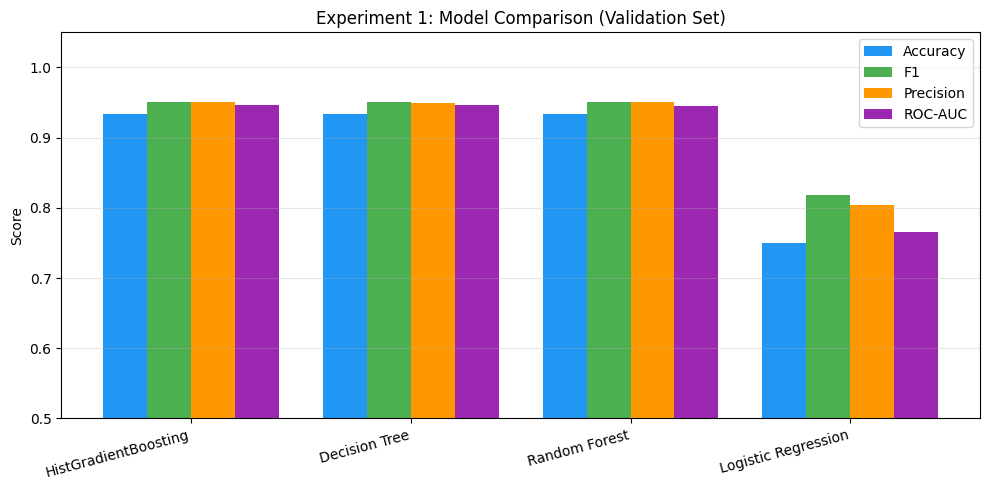

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(comp_df))
width  = 0.2
metrics = ['Accuracy', 'F1', 'Precision', 'ROC-AUC']
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, comp_df[metric], width, label=metric, color=color)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comp_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Experiment 1: Model Comparison (Validation Set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('docs/figures/exp1_model_comparison.png', dpi=150)
plt.show()

## Experiment 2 - Feature Ablation

Wanted to check whether the extra feature groups (deltas, rolling stats, ratios) are actually useful or just adding noise. Using HistGradBoost as the base model since it came out best in experiment 1.

In [12]:
ABLATION_SETS = {
    'A: Raw signals only':         GROUP_A,
    'A+B: + Deltas':               GROUP_A + GROUP_B,
    'A+B+C: + Rolling stats':      GROUP_A + GROUP_B + GROUP_C,
    'A+B+C+D: + Ratio (full set)': ALL_FEATURES,
}

ablation_results = []

for label_ab, feat_cols in ABLATION_SETS.items():
    idx     = [ALL_FEATURES.index(f) for f in feat_cols]
    Xtr_ab  = X_train_sm[:, idx]
    Xvl_ab  = X_val[:, idx]

    mdl_ab = HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=500, max_depth=8,
        class_weight='balanced', random_state=42
    )
    mdl_ab.fit(Xtr_ab, y_train_sm)
    yv_ab   = mdl_ab.predict(Xvl_ab)
    yv_prob = mdl_ab.predict_proba(Xvl_ab)[:, 1]

    ablation_results.append({
        'Feature Set':   label_ab,
        'Num Features':  len(feat_cols),
        'Accuracy':      accuracy_score(y_val, yv_ab),
        'F1':            f1_score(y_val, yv_ab),
        'ROC-AUC':       roc_auc_score(y_val, yv_prob),
    })
    print(f"  {label_ab:35s}  "
          f"F1={ablation_results[-1]['F1']:.4f}  "
          f"AUC={ablation_results[-1]['ROC-AUC']:.4f}")

abl_df = pd.DataFrame(ablation_results)
abl_df.set_index('Feature Set').style.format('{:.4f}', subset=['Accuracy','F1','ROC-AUC']).highlight_max(color='lightgreen', subset=['F1','ROC-AUC'])

  A: Raw signals only                  F1=0.7381  AUC=0.6577
  A+B: + Deltas                        F1=0.9510  AUC=0.9461
  A+B+C: + Rolling stats               F1=0.9510  AUC=0.9466
  A+B+C+D: + Ratio (full set)          F1=0.9510  AUC=0.9469


,Num Features,Accuracy,F1,ROC-AUC
Feature Set,,,,
A: Raw signals only,7,0.6432,0.7381,0.6577
A+B: + Deltas,12,0.9338,0.9510,0.9461
A+B+C: + Rolling stats,36,0.9338,0.9510,0.9466
A+B+C+D: + Ratio (full set),41,0.9338,0.9510,0.9469


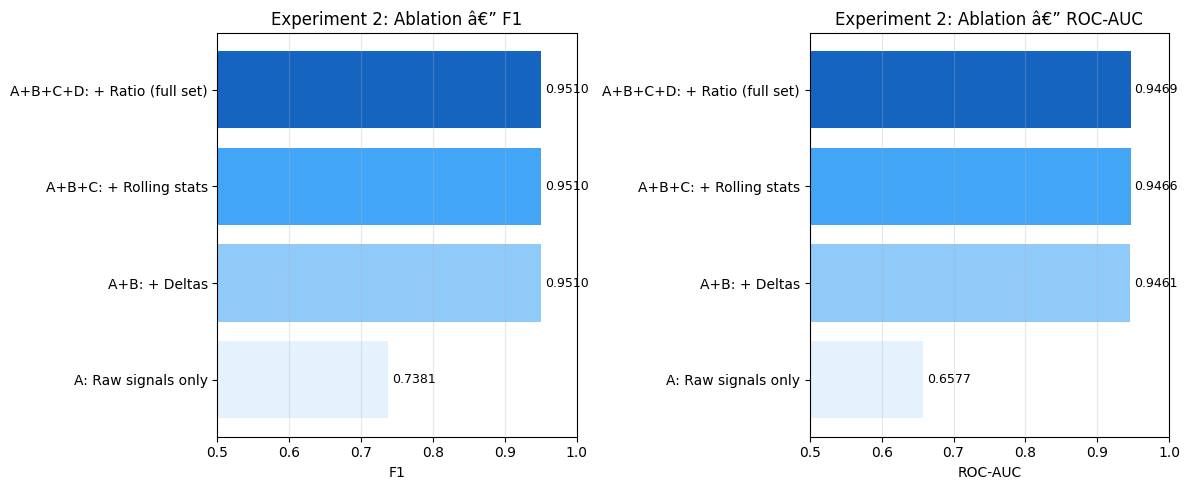

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bar_colors = ['#E3F2FD','#90CAF9','#42A5F5','#1565C0']
for ax, metric in zip(axes, ['F1', 'ROC-AUC']):
    ax.barh(abl_df['Feature Set'], abl_df[metric], color=bar_colors)
    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel(metric)
    ax.set_title(f'Experiment 2: Ablation â€” {metric}')
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(abl_df[metric]):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('docs/figures/exp2_ablation.png', dpi=150)
plt.show()

## Experiment 3 - Cross-Driver Leave-One-Out

This checks how well the model generalises to a driver it has never seen. Each Kaggle driver gets held out once as the test set, and the model is retrained on the remaining drivers plus synthetic and real trip data.

In [14]:
drivers = sorted(df_kaggle['driver_id'].unique().astype(int).tolist())
loo_results = []

for test_driver in drivers:
    mask_test  = df['driver_id'] == test_driver
    mask_train = ~mask_test

    X_loo_train = df.loc[mask_train, ALL_FEATURES].values
    y_loo_train = df.loc[mask_train, 'label'].values.astype(int)
    X_loo_test  = df.loc[mask_test,  ALL_FEATURES].values
    y_loo_test  = df.loc[mask_test,  'label'].values.astype(int)

    sm = SMOTE(random_state=42)
    Xlt, ylt = sm.fit_resample(X_loo_train, y_loo_train)

    mdl_loo = HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=500, max_depth=8,
        class_weight='balanced', random_state=42
    )
    mdl_loo.fit(Xlt, ylt)
    yp      = mdl_loo.predict(X_loo_test)
    yp_prob = mdl_loo.predict_proba(X_loo_test)[:, 1]

    loo_results.append({
        'Test Driver':   int(test_driver),
        'Train Drivers': [d for d in drivers if d != test_driver],
        'Accuracy':      accuracy_score(y_loo_test, yp),
        'F1':            f1_score(y_loo_test, yp),
        'ROC-AUC':       roc_auc_score(y_loo_test, yp_prob),
    })
    print(f"  Driver {test_driver} held out -> "
          f"Acc={loo_results[-1]['Accuracy']:.4f}  "
          f"F1={loo_results[-1]['F1']:.4f}  "
          f"AUC={loo_results[-1]['ROC-AUC']:.4f}")

loo_df = pd.DataFrame(loo_results)
print(f"\nLOO Mean  -> F1={loo_df['F1'].mean():.4f} +/- {loo_df['F1'].std():.4f}  "
      f"AUC={loo_df['ROC-AUC'].mean():.4f} +/- {loo_df['ROC-AUC'].std():.4f}")

  Driver 1 held out -> Acc=0.9548  F1=0.9660  AUC=0.9675
  Driver 2 held out -> Acc=0.9466  F1=0.9541  AUC=0.9614
  Driver 3 held out -> Acc=0.8767  F1=0.9227  AUC=0.8223

LOO Mean  -> F1=0.9476 +/- 0.0224  AUC=0.9170 +/- 0.0821


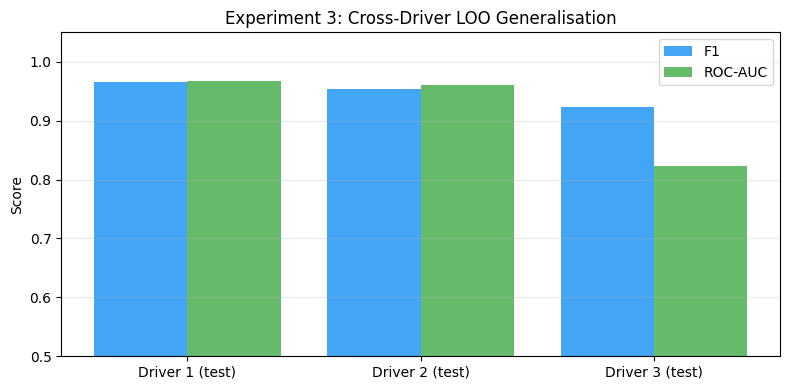

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(loo_df))
ax.bar(x - 0.2, loo_df['F1'],      0.4, label='F1',      color='#42A5F5')
ax.bar(x + 0.2, loo_df['ROC-AUC'], 0.4, label='ROC-AUC', color='#66BB6A')
ax.set_xticks(x)
ax.set_xticklabels([f'Driver {d} (test)' for d in loo_df['Test Driver']])
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Experiment 3: Cross-Driver LOO Generalisation')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('docs/figures/exp3_cross_driver_loo.png', dpi=150)
plt.show()

## Experiment 4 - Learning Curve

Just want to confirm the model is not overfitting. If training F1 is much higher than cross-val F1, that is a problem.

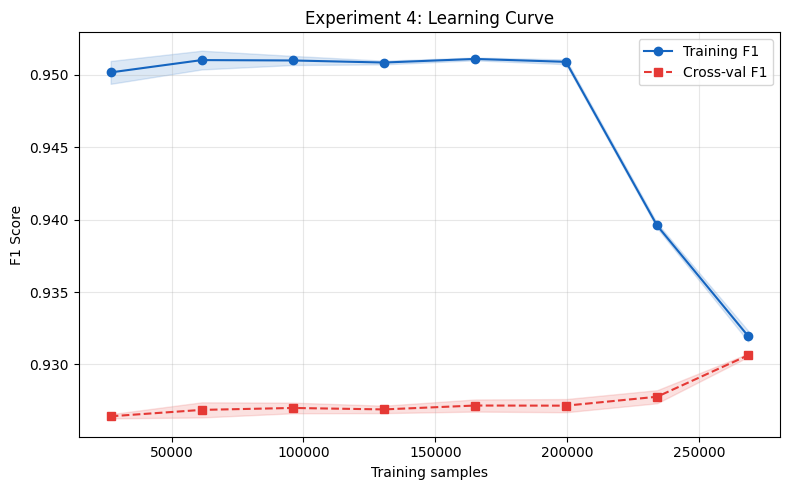

In [16]:
lc_model = HistGradientBoostingClassifier(
    learning_rate=0.05, max_iter=500, max_depth=8,
    class_weight='balanced', random_state=42
)
train_sizes_abs, train_scores, val_scores = learning_curve(
    lc_model, X_train_sm, y_train_sm,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1', n_jobs=1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes_abs, train_scores.mean(axis=1), 'o-',
        color='#1565C0', label='Training F1')
ax.fill_between(train_sizes_abs,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1),
                alpha=0.15, color='#1565C0')
ax.plot(train_sizes_abs, val_scores.mean(axis=1), 's--',
        color='#E53935', label='Cross-val F1')
ax.fill_between(train_sizes_abs,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1),
                alpha=0.15, color='#E53935')
ax.set_xlabel('Training samples')
ax.set_ylabel('F1 Score')
ax.set_title('Experiment 4: Learning Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('docs/figures/exp4_learning_curve.png', dpi=150)
plt.show()

## Stage 6 - Final Model

Now that I have picked the best model and confirmed the features are working, I train on train+val combined and evaluate on the held-out test set (which was never touched during experiments).

In [17]:
X_tv = np.concatenate([X_train_sm, X_val])
y_tv = np.concatenate([y_train_sm, y_val])

final_model = HistGradientBoostingClassifier(
    learning_rate=0.05, max_iter=500, max_depth=8,
    class_weight='balanced', random_state=42
)
final_model.fit(X_tv, y_tv)

y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_test_pred)
f1  = f1_score(y_test, y_test_pred)
pre = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_prob)

print("=== FINAL TEST SET RESULTS ===")
print(f"Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"F1 Score  : {f1:.4f}")
print(f"Precision : {pre:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=['Safe','Aggressive']))

=== FINAL TEST SET RESULTS ===
Accuracy  : 0.9333  (93.33%)
F1 Score  : 0.9505
Precision : 0.9520
Recall    : 0.9490
ROC-AUC   : 0.9471

              precision    recall  f1-score   support

        Safe       0.89      0.90      0.90     20810
  Aggressive       0.95      0.95      0.95     43150

    accuracy                           0.93     63960
   macro avg       0.92      0.92      0.92     63960
weighted avg       0.93      0.93      0.93     63960



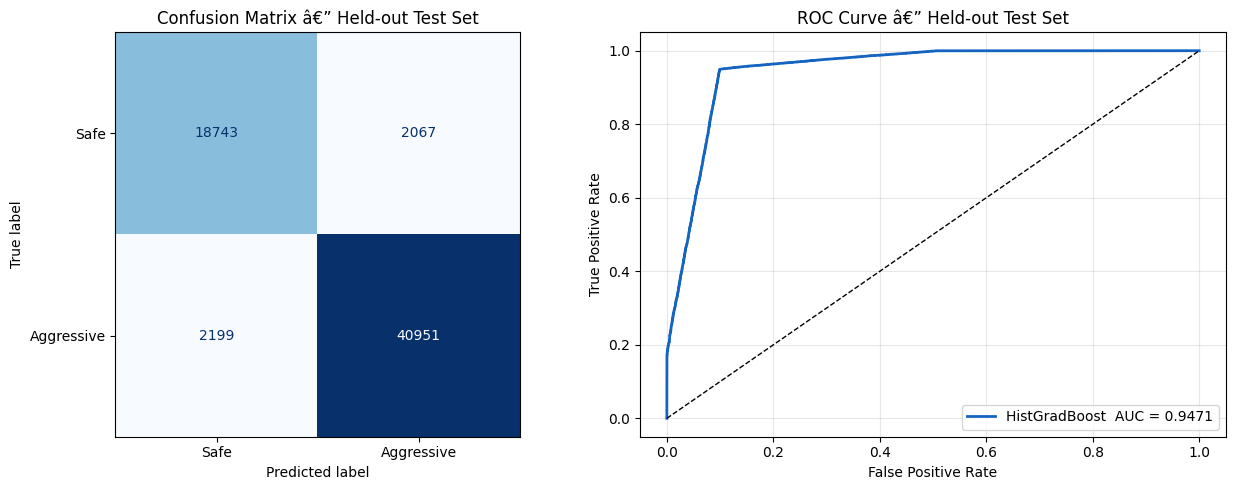

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm   = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Aggressive'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix â€” Held-out Test Set')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, lw=2, color='#1565C0',
             label=f'HistGradBoost  AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve â€” Held-out Test Set')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('docs/figures/final_evaluation.png', dpi=150)
plt.show()

## Stage 7 - Save Model and Scaler

In [19]:
MODEL_PATH  = 'src/models/fyp_model.pkl'
SCALER_PATH = 'src/models/fyp_scaler.pkl'
META_PATH   = 'src/models/fyp_model_meta.json'

joblib.dump(final_model, MODEL_PATH)
joblib.dump(scaler,      SCALER_PATH)
print(f"Model  saved -> {MODEL_PATH}")
print(f"Scaler saved -> {SCALER_PATH}")

meta = {
    'trained_at':     datetime.now().isoformat(),
    'dataset':        'Combined: Kaggle OBD-II + Car-Specific Synthetic + Real Trip CSVs',
    'label_source':   'Balanced-v2 rules: RPM>2700&Thr>30 | Load>92&Thr>30 | SpeedChange>12',
    'features':       ALL_FEATURES,
    'signal_cols':    SIGNAL_COLS,
    'n_features':     len(ALL_FEATURES),
    'split':          '70/15/15 stratified',
    'smote':          'Applied to training fold only',
    'model':          'HistGradientBoostingClassifier',
    'hyperparams':    {'learning_rate': 0.05, 'max_iter': 500, 'max_depth': 8},
    'test_accuracy':  round(acc, 4),
    'test_f1':        round(f1,  4),
    'test_precision': round(pre, 4),
    'test_recall':    round(rec, 4),
    'test_roc_auc':   round(auc, 4),
    'loo_f1_mean':    round(float(loo_df['F1'].mean()), 4),
    'loo_f1_std':     round(float(loo_df['F1'].std()),  4),
}
with open(META_PATH, 'w') as mf:
    json.dump(meta, mf, indent=2)
print(f"Metadata saved -> {META_PATH}")

Model  saved -> src/models/fyp_model.pkl
Scaler saved -> src/models/fyp_scaler.pkl
Metadata saved -> src/models/fyp_model_meta.json
